# Analysis of the HARPS-N data using the <tt>fdac</tt> module

In this example we analyze the RV data published by Stalport et al. 2023 on HD 99492 from HARPS-N. The data is a good test case for our methodology since it contains 4 activity indicators along with the RV time series


#### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#make better plots
import scienceplots
plt.style.use(['science','notebook','grid'])
plt.rcParams.update({"font.size" : 26})
plt.rcParams.update({"axes.labelsize" : 26})
plt.rcParams.update({"xtick.labelsize" : 22})
plt.rcParams.update({"ytick.labelsize" : 22})
plt.rcParams.update({"axes.titlesize" : 26})
plt.rcParams.update({"figure.figsize": (9,6)})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

## 1. Read the data

In [2]:
#read the data
data = pd.read_csv('../../data/HARPSHD99492.tsv', sep='\t', comment='#')
data= data.drop([0,1]).reset_index(drop=True)
data= data.apply(pd.to_numeric)
data.head()

,BJD,RV,e_RV,SMW,e_SMW,FWHM,e_FWHM,Cont,e_Cont,Ha,e_Ha
0,56665.72940,6.47,0.18,0.110776,0.000335,6.033186,0.000578,0.598509,0.000056,0.260070,0.000286
1,56668.73828,1.00,0.19,0.107735,0.000307,6.032374,0.000630,0.598558,0.000061,0.258670,0.000311
2,56671.72642,-5.62,0.19,0.114098,0.000312,6.035602,0.000608,0.598372,0.000059,0.260416,0.000287
3,56672.72664,-6.13,0.20,0.123093,0.000226,6.037457,0.000666,0.598040,0.000065,0.259783,0.000209
4,56737.57865,1.72,0.28,0.129404,0.000340,6.037482,0.000911,0.597844,0.000089,0.260505,0.000297


/var/folders/yk/b36tymm90p1cnv5qffdwp2z40000gn/T/ipykernel_39871/4025101576.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Blues_r')


Text(0.5, 0, 'BJD')

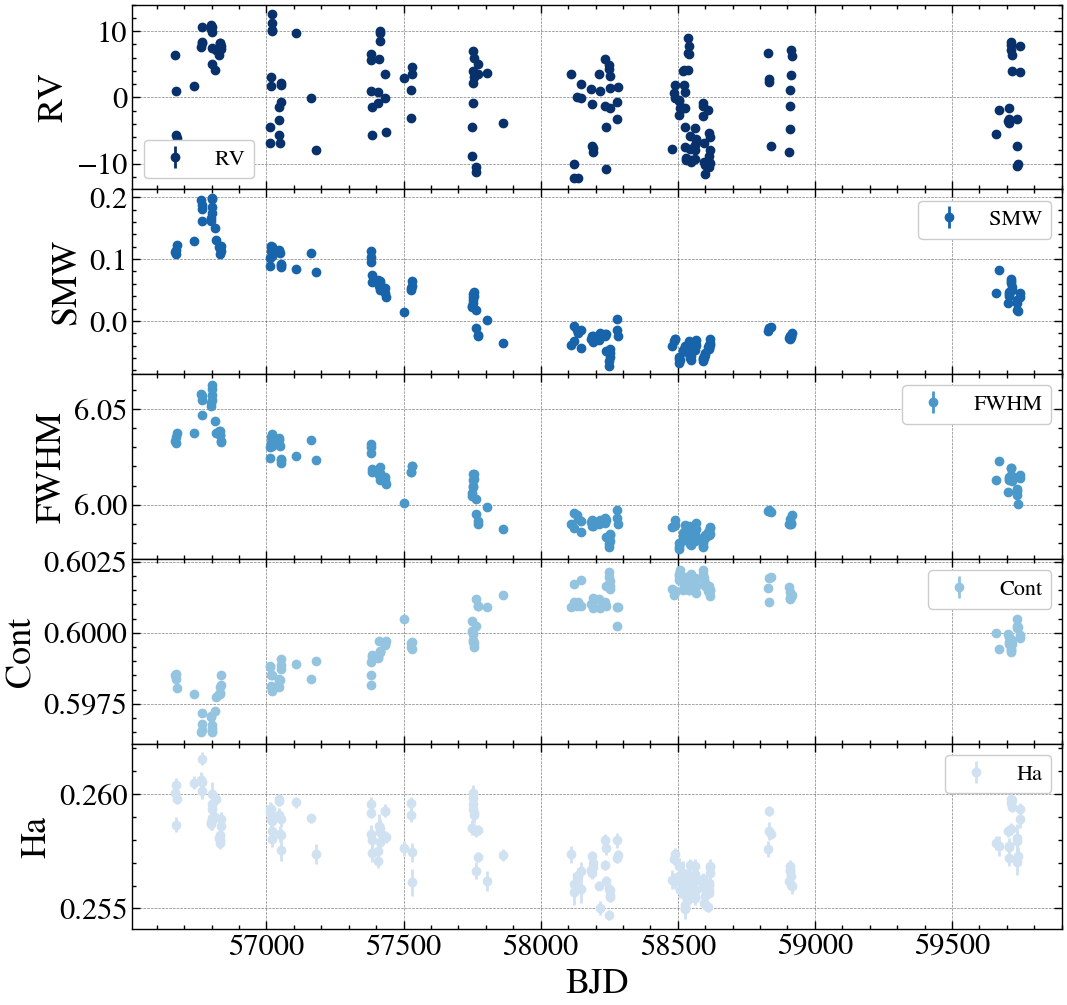

In [3]:
#plot the data
labels = data.columns

import random

number_of_colors = 5

cmap = plt.cm.get_cmap('Blues_r')
colors= cmap(np.linspace(0,0.8,number_of_colors))

fig, ax = plt.subplots(nrows = 5, ncols=1, figsize=(12,12), sharex = True, \
                               gridspec_kw = {'wspace':0, 'hspace':0})
for i in range(5):
    ax[i].errorbar(data[labels[0]], data[labels[1+i*2]], yerr = data[labels[i*2+2]], fmt='o', \
                   label= labels[i*2+1], color = colors[i])
    ax[i].legend()
    ax[i].set_ylabel(labels[i*2+1])
ax[i].set_xlabel(labels[0])

## 2. Create the fdac object

In [4]:
import sys
import os

# Get the path to the src folder relative to the notebook
src_path = os.path.abspath(os.path.join(os.pardir,os.pardir, "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

#Import the module
from fdac import fdac

In [5]:
data.columns

Index(['BJD', 'RV', 'e_RV', 'SMW', 'e_SMW', 'FWHM', 'e_FWHM', 'Cont', 'e_Cont',
       'Ha', 'e_Ha'],
      dtype='object')

In [6]:
timeseries = np.array((data['SMW'],data['FWHM'], data['Cont'],data['Ha']))
rvs = np.array(data['RV'])
time =np.array(data['BJD'])
fdac = fdac.fdac(time,rvs, timeseries, ['RV', 'SMW', 'FWHM', "Cont", "Ha"])

Mean Nyquist frequency:  0.028384642516091515 

Median Nyquist frequency:  0.47904191616900044 

10% trimmed Mean Nyquist frequency:  0.07874735561179494 

20% trimmed mean Nyqusit frequenct:  0.12371376292273806


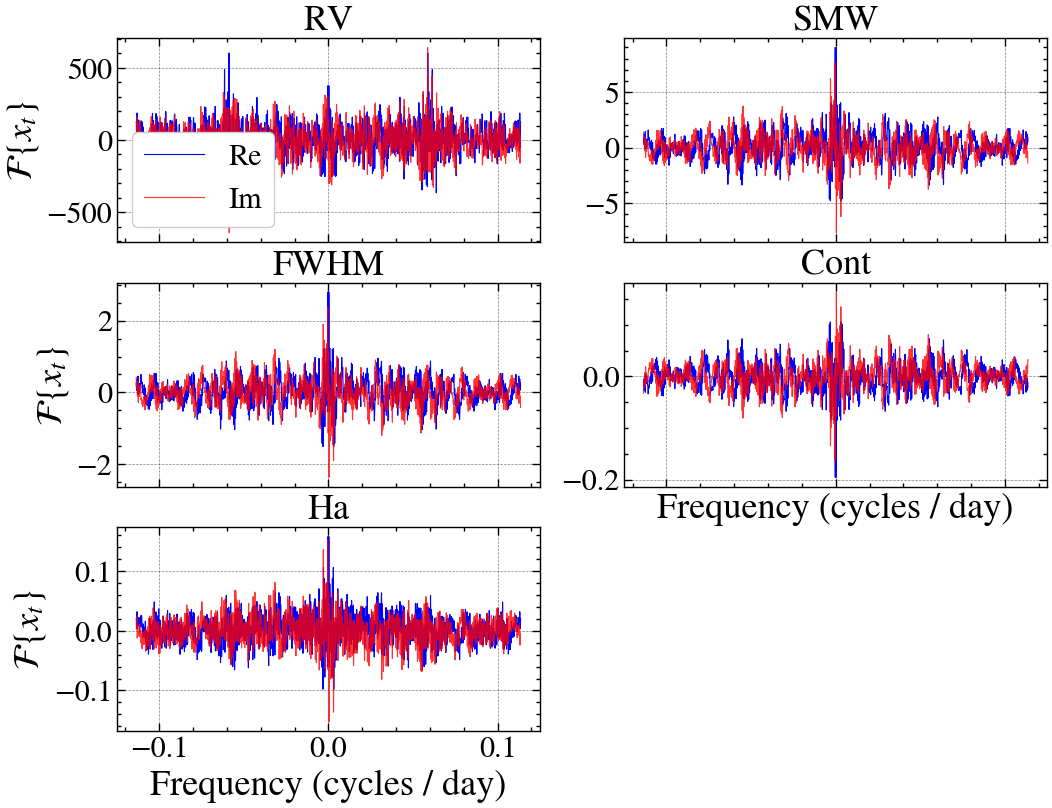

In [7]:
fdac.frequency_grid(4*fdac.Nyq_meandt, oversample=4)
fdac.computeNFFT()
fdac.plotNFFT()

## 3. Fit the Multiple Linear Regression to the observations

In [8]:
fdac.linear_reg()

Coefficients
----
Coefficients: 
 [[ -317.40351854    18.37579841   890.68791856    23.19274756
  -3711.27374371   847.75940659   484.13884049   213.14644405]
 [  -17.07144039  -327.05259843    -7.98620789   905.25333535
   -536.08922894 -3918.17274711  -102.05122887   446.53948486]]

Intercept
---------
Intercept: 
 0.0


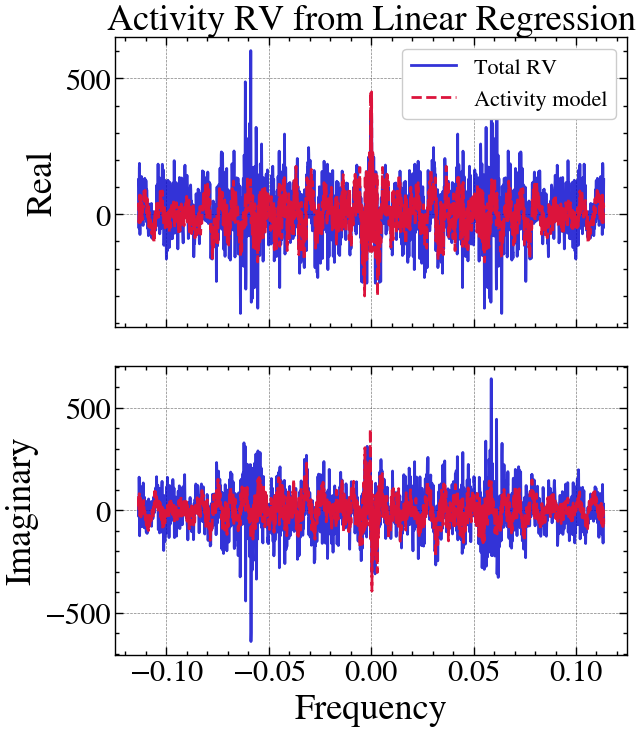

In [9]:
fdac.fftac_plot()

## 4. Get the time domain activity model and subtract to the residuals

43.731346829933166 1.1965700117128984e-06
Raw standard deviation 6.3682
Variance ratio: 0.3964
Should be 1: 1.0
Should be equal: 4.0093 4.0093
Inversion fully computed
Std dev of clean RV: 10.133227496122345


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


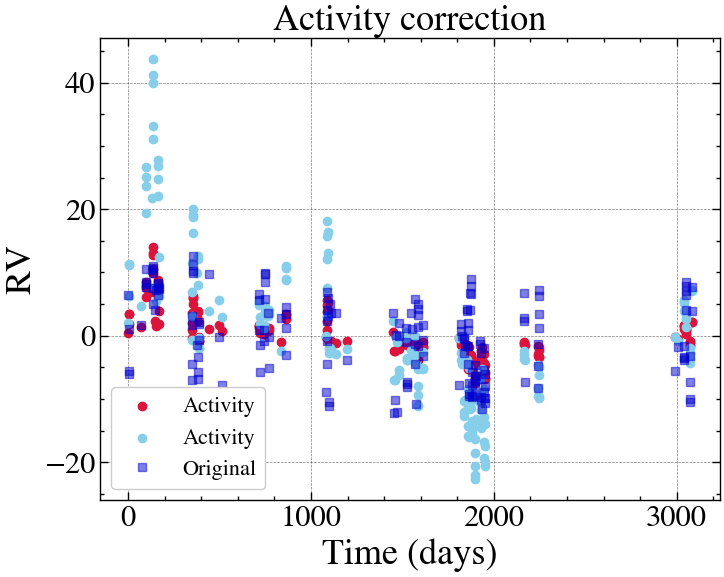

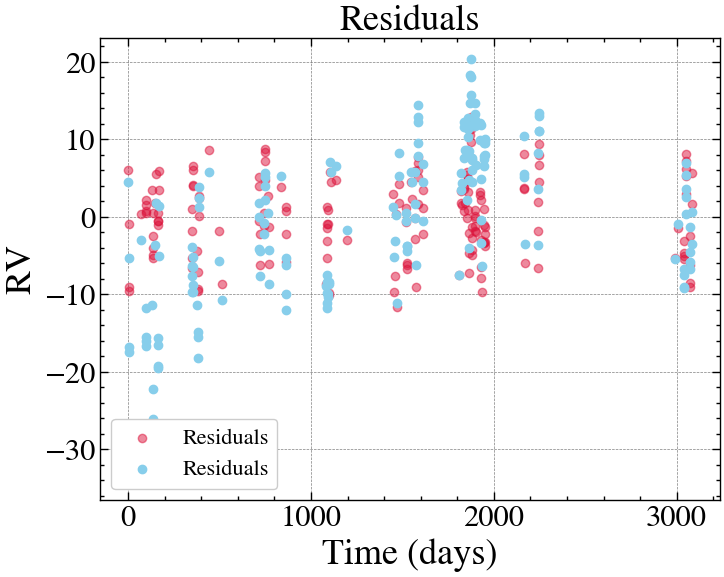

In [10]:
fdac.inverfft()
fdac.activityplot(clean = True)

## 5. Analyze the performance of the acitivy model in subtracting the stellar signals in the data

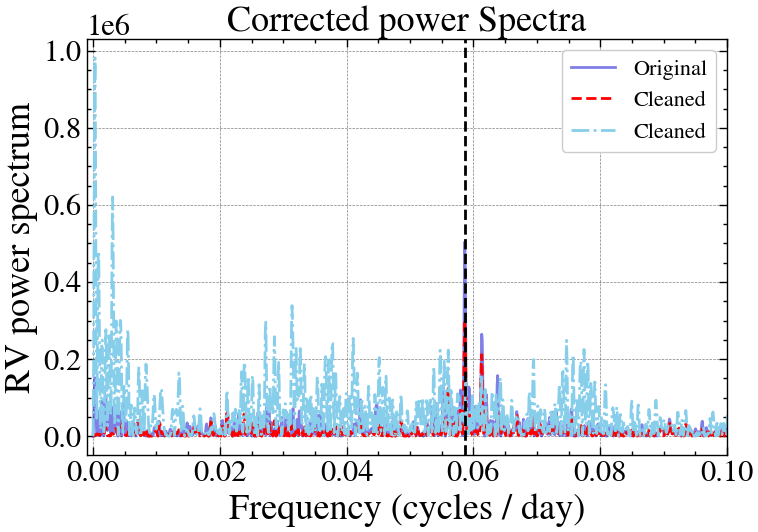

In [21]:
fdac.residual_powplot()
#plt.ylim(1e-2, 1e7)
plt.xlim(-0.001,0.1)
plt.axvline(1/17.05, color='k', ls='--')

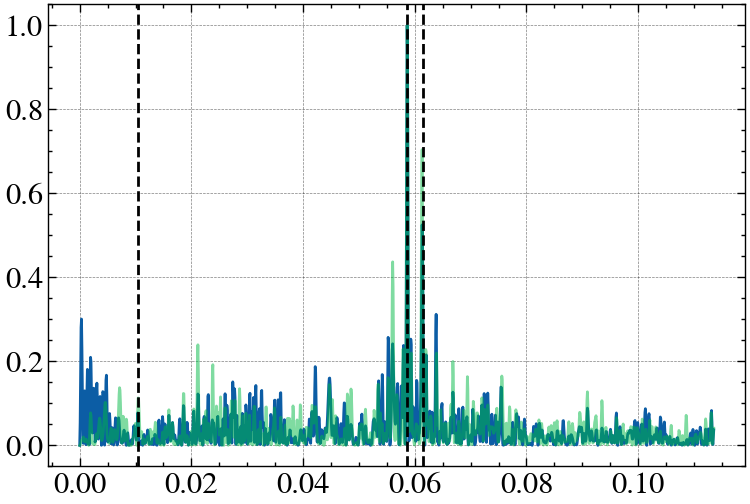

In [29]:
indeces = fdac.fgrid>=0
plt.plot(fdac.fgrid[indeces], np.abs(fdac.first_FFT[indeces])**2/np.max(np.abs(fdac.first_FFT[indeces])**2))
plt.plot(fdac.fgrid[indeces], np.abs(fdac.residuals_FFT[indeces])**2/np.max(np.abs(fdac.residuals_FFT[indeces])**2),alpha=0.5)
plt.axvline(1/17.05, color='k', ls='--')
plt.axvline(1/17.05 +1/365.25, color='k', ls='--')
plt.axvline(1/95.4, color= 'k', ls='--')